<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Mahalanabis_distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mu = [1.  0.5]
Sigma =
 [[3. 1.]
 [1. 2.]]

Eigenvalues (lambda): [3.61803399 1.38196601]
Eigenvectors (columns are u_i):
 [[-0.85065081  0.52573111]
 [-0.52573111 -0.85065081]]

Test point x = [ 3.2 -0.4]
x - mu = [ 2.2 -0.9]

Coordinates in eigenbasis y = [-1.39827378  1.92219417]

Delta^2 (direct) = 3.214000000000
Delta^2 (sum y_i^2/lambda_i) = 3.214000000000

Reconstruction Sigma_recon:
 [[3. 1.]
 [1. 2.]]

Inverse reconstruction Sigma_inv_recon:
 [[ 0.4 -0.2]
 [-0.2  0.6]]

Difference Sigma - Sigma_recon (should be near zero):
 [[4.44089210e-16 2.22044605e-16]
 [2.22044605e-16 6.66133815e-16]]

Difference inv(Sigma) - Sigma_inv_recon (should be near zero):
 [[5.55111512e-17 0.00000000e+00]
 [0.00000000e+00 1.11022302e-16]]


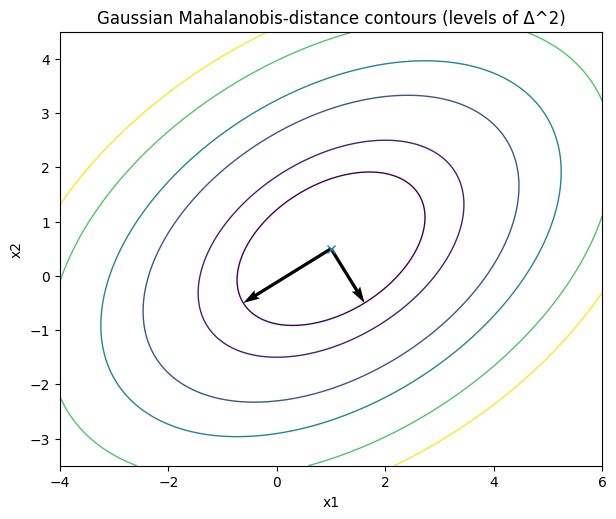

In [1]:
# Algebraic derivation + numerical demonstration and visualization
import numpy as np
import matplotlib.pyplot as plt

# 1) Choose a 2D mean and covariance
mu = np.array([1.0, 0.5])
Sigma = np.array([[3.0, 1.0],
                  [1.0, 2.0]])

# 2) Eigen-decomposition of Sigma
eigvals, eigvecs = np.linalg.eigh(Sigma)  # eigh returns sorted eigenvalues for symmetric matrices
# Order them descending for readability
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# 3) A random test point
x = np.array([3.2, -0.4])

# 4) Compute delta^2 directly and via eigen-coordinates
dx = x - mu
delta2_direct = dx.T @ np.linalg.inv(Sigma) @ dx

# Coordinates in eigenbasis: y_i = u_i^T (x-mu)
y = eigvecs.T @ dx
delta2_eigsum = np.sum((y**2) / eigvals)

# 5) Reconstruction check: Sigma == sum lambda_i u_i u_i^T
Sigma_recon = sum(eigvals[i] * np.outer(eigvecs[:, i], eigvecs[:, i]) for i in range(len(eigvals)))
Sigma_inv_recon = sum((1.0 / eigvals[i]) * np.outer(eigvecs[:, i], eigvecs[:, i]) for i in range(len(eigvals)))

# Print numeric checks
print("mu =", mu)
print("Sigma =\n", Sigma)
print("\nEigenvalues (lambda):", eigvals)
print("Eigenvectors (columns are u_i):\n", eigvecs)
print("\nTest point x =", x)
print("x - mu =", dx)
print("\nCoordinates in eigenbasis y =", y)
print(f"\nDelta^2 (direct) = {delta2_direct:.12f}")
print(f"Delta^2 (sum y_i^2/lambda_i) = {delta2_eigsum:.12f}")
print("\nReconstruction Sigma_recon:\n", Sigma_recon)
print("\nInverse reconstruction Sigma_inv_recon:\n", Sigma_inv_recon)
print("\nDifference Sigma - Sigma_recon (should be near zero):\n", Sigma - Sigma_recon)
print("\nDifference inv(Sigma) - Sigma_inv_recon (should be near zero):\n", np.linalg.inv(Sigma) - Sigma_inv_recon)

# 6) Visualization: gaussian contours and eigenvectors
# prepare grid
n = 200
x1 = np.linspace(mu[0]-5, mu[0]+5, n)
x2 = np.linspace(mu[1]-4, mu[1]+4, n)
X1, X2 = np.meshgrid(x1, x2)
pos = np.stack([X1, X2], axis=-1)

# compute Mahalanobis exponent (unnormalised)
Sigma_inv = np.linalg.inv(Sigma)
expo = np.empty((n, n))
for i in range(n):
    for j in range(n):
        v = pos[i, j] - mu
        expo[i, j] = v.T @ Sigma_inv @ v

# plot
fig, ax = plt.subplots(figsize=(7,6))
CS = ax.contour(X1, X2, expo, levels=[1,2,4,6,9,12], linewidths=1)
ax.set_aspect('equal', adjustable='box')
ax.set_title("Gaussian Mahalanobis-distance contours (levels of Δ^2)")
ax.set_xlabel('x1'); ax.set_ylabel('x2')

# plot mean
ax.plot(mu[0], mu[1], marker='x')

# plot eigenvectors scaled by sqrt(lambda) to show principal axes lengths
for i in range(len(eigvals)):
    u = eigvecs[:, i]
    # length proportional to sqrt(lambda) (one-std dev along that direction)
    length = np.sqrt(eigvals[i])
    ax.quiver(mu[0], mu[1], u[0]*length, u[1]*length, angles='xy', scale_units='xy', scale=1, width=0.006)

plt.show()
